In [42]:
import subprocess
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [58]:
try:
    # 1. 运行 C++ 程序并捕获输出
    executable = "../anchor_mapping"
    args = [
        "--max_node_capacity", "10",
        "--leaf_radius_threshold", "0",
        "--compactness_min_capacity", "1000",
        "--compactness_radius_factor", "1000"
    ]
    command = [executable] + args

    result = subprocess.run(
        command,  # 正确地传入分解后的列表
        capture_output=True,
        text=True,
        check=True
    )
    output = result.stdout
    
except FileNotFoundError:
    print(f"错误: 找不到可执行文件。请确保文件路径正确且已编译。")
except subprocess.CalledProcessError as e:
    print(f"错误: C++ 程序运行失败，退出码 {e.returncode}。")
    print("--- C++ 错误输出 ---")
    print(e.stderr)

# 2. 解析 C++ 输出中的数据
parsed_data = {} # 结构: {layer: {'total': N, 'multi_contained': M, 'total_overlap': T}}

# 正则表达式用于匹配新的输出格式
# 匹配 父层级: (N) | 子节点总数: (N) | 被多次覆盖枢轴数: (N) (...) | 总重叠次数: (N)
pattern = re.compile(
    r"父层级:\s+(\d+)\s+\|\s+子节点总数:\s+(\d+)\s+\|\s+被多次覆盖枢轴数:\s+(\d+)\s+.*?\s+\|\s+总重叠次数:\s+(\d+)"
)

for line in output.splitlines():
    match = pattern.search(line)
    if match:
        layer = int(match.group(1))
        total_nodes = int(match.group(2))
        multi_contained = int(match.group(3))
        total_overlap = int(match.group(4))
        
        parsed_data[layer] = {
            'total': total_nodes,
            'multi_contained': multi_contained,
            'total_overlap': total_overlap
        }

if not parsed_data:
    print("警告: 未能在 C++ 输出中找到重叠度数据。请检查 C++ 输出格式是否符合预期。")
    print("--- C++ 原始输出 ---")
    print(output)


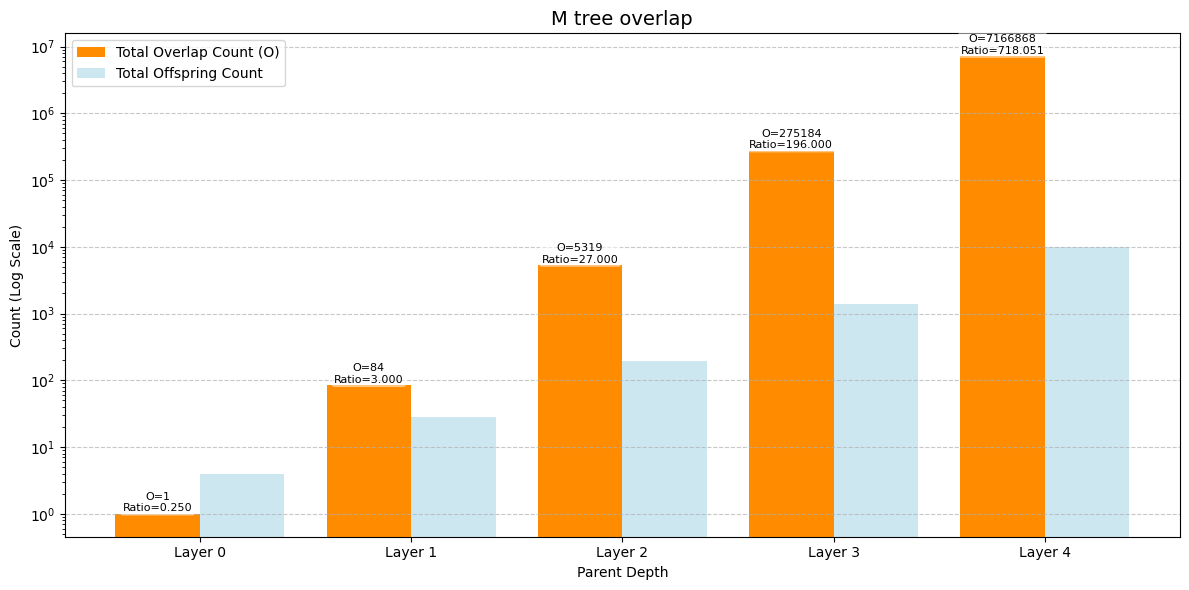

In [59]:
# 3. 准备绘图数据
layers = sorted(parsed_data.keys())
# 绘制总重叠次数
total_overlap_counts = [parsed_data[l]['total_overlap'] for l in layers]
total_nodes_counts = [parsed_data[l]['total'] for l in layers]
T_plot_values = np.clip(total_overlap_counts, a_min=1, a_max=None) # 用于绘图
layer_labels = [f'Layer {l}' for l in layers]
x = np.arange(len(layer_labels)) # x 轴标签位置
layer_labels = [f'Layer {l}' for l in layers]
x = np.arange(len(layer_labels))  # x 轴标签位置
bar_width = 0.4 # 柱子宽度

# 4. 绘制单图表 (无 Subplot)
plt.figure(figsize=(12, 6))
ax = plt.gca() # 获取当前的 Axes 对象

# --- 绘制总重叠次数 (T) ---
# 注意：使用 total_overlap_counts 对应您的 bars1
bars1 = ax.bar(x - bar_width/2, T_plot_values, bar_width, label='Total Overlap Count (O)', color='darkorange')

# --- 绘制总子节点数 (Total) 作为参考柱 ---
bars2 = ax.bar(x + bar_width/2, total_nodes_counts, bar_width, label='Total Offspring Count', color='lightblue', alpha=0.6)

# --- 设置 Y 轴为对数刻度 ---
ax.set_yscale('log')
ax.set_title('M tree overlap', fontsize=14)
ax.set_xlabel('Parent Depth')
ax.set_ylabel('Count (Log Scale)')
ax.set_xticks(x)
ax.set_xticklabels(layer_labels)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend()

# 5. 添加数值标签和比值
for i, bar in enumerate(bars1):
    yval = bar.get_height()
    total_node_count = total_nodes_counts[i]
    
    # 避免除以零
    overlap_ratio = yval / total_node_count if total_node_count > 0 else 0.0
    
    # 显示总重叠次数和比值
    label_text = f'O={int(yval)}\nRatio={overlap_ratio:.3f}'
    
    # 在柱子上方放置标签
    # 由于是 log 刻度，需要稍微调整 y 位置
    ax.text(bar.get_x() + bar.get_width()/2, yval*1.02, label_text, 
            ha='center', va='bottom', fontsize=8, color='black', 
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round, pad=0.2')) 

plt.tight_layout()
plt.show()

In [60]:
try:
    # 1. 运行 C++ 程序并捕获输出
    # 1. 运行 C++ 程序并捕获输出
    executable = "../anchor_mapping"
    args = [
        "--max_node_capacity", "10",
        "--leaf_radius_threshold", "6",
        "--compactness_min_capacity", "8",
        "--compactness_radius_factor", "1.1"
    ]
    command = [executable] + args

    result = subprocess.run(
        command,  # 正确地传入分解后的列表
        capture_output=True,
        text=True,
        check=True
    )
    output = result.stdout
    
except FileNotFoundError:
    print(f"错误: 找不到可执行文件。请确保文件路径正确且已编译。")
except subprocess.CalledProcessError as e:
    print(f"错误: C++ 程序运行失败，退出码 {e.returncode}。")
    print("--- C++ 错误输出 ---")
    print(e.stderr)

# 2. 解析 C++ 输出中的数据
parsed_data = {} # 结构: {layer: {'total': N, 'multi_contained': M, 'total_overlap': T}}

# 正则表达式用于匹配新的输出格式
# 匹配 父层级: (N) | 子节点总数: (N) | 被多次覆盖枢轴数: (N) (...) | 总重叠次数: (N)
pattern = re.compile(
    r"父层级:\s+(\d+)\s+\|\s+子节点总数:\s+(\d+)\s+\|\s+被多次覆盖枢轴数:\s+(\d+)\s+.*?\s+\|\s+总重叠次数:\s+(\d+)"
)

for line in output.splitlines():
    match = pattern.search(line)
    if match:
        layer = int(match.group(1))
        total_nodes = int(match.group(2))
        multi_contained = int(match.group(3))
        total_overlap = int(match.group(4))
        
        parsed_data[layer] = {
            'total': total_nodes,
            'multi_contained': multi_contained,
            'total_overlap': total_overlap
        }

if not parsed_data:
    print("警告: 未能在 C++ 输出中找到重叠度数据。请检查 C++ 输出格式是否符合预期。")
    print("--- C++ 原始输出 ---")
    print(output)


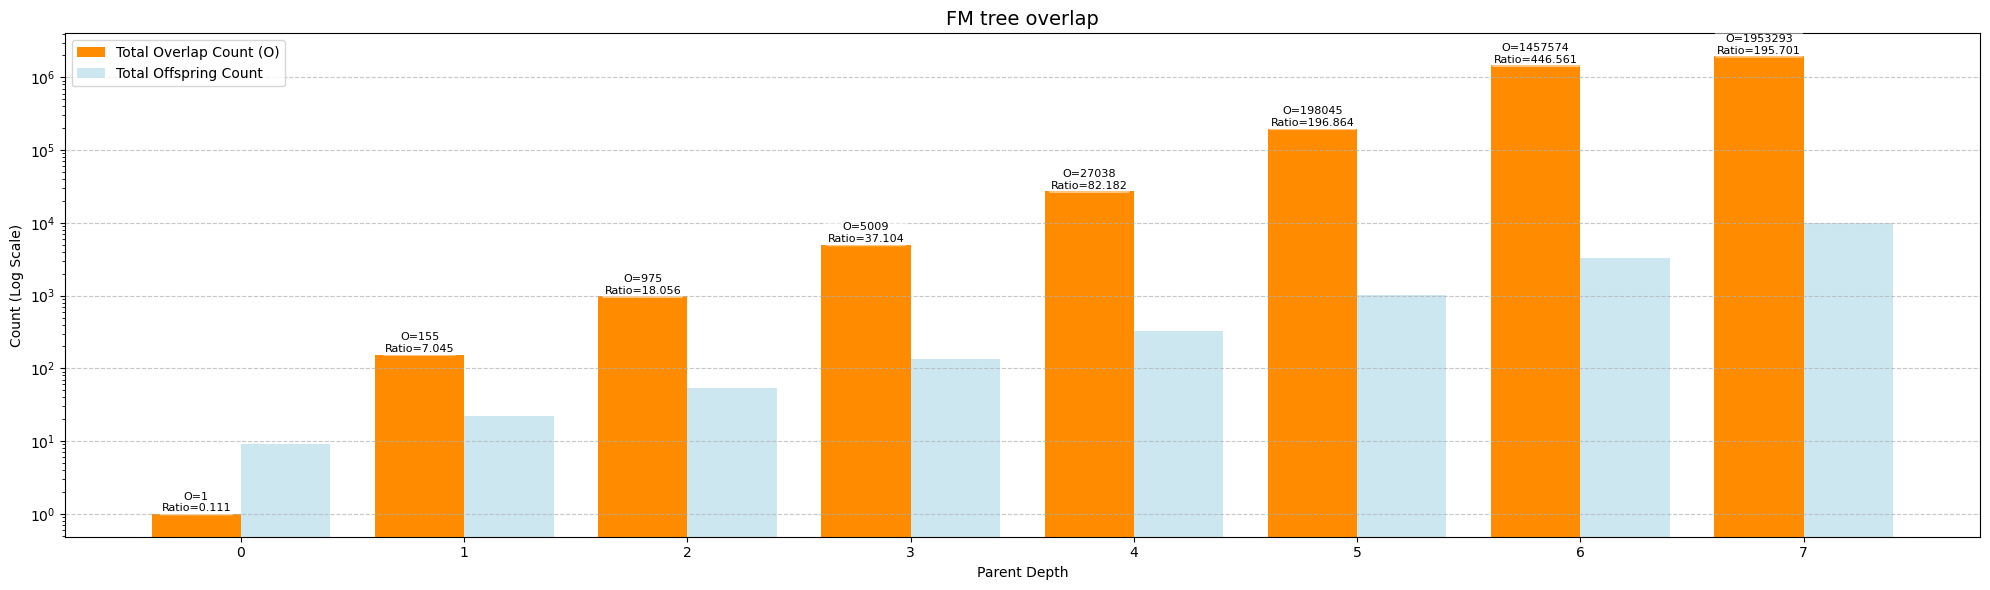

In [61]:
# 3. 准备绘图数据
layers = sorted(parsed_data.keys())
# 绘制总重叠次数
total_overlap_counts = [parsed_data[l]['total_overlap'] for l in layers]
total_nodes_counts = [parsed_data[l]['total'] for l in layers]
T_plot_values = np.clip(total_overlap_counts, a_min=1, a_max=None) # 用于绘图
layer_labels = [l for l in layers]
x = np.arange(len(layer_labels)) # x 轴标签位置
layer_labels = [l for l in layers]
x = np.arange(len(layer_labels))  # x 轴标签位置
bar_width = 0.4 # 柱子宽度

# 4. 绘制单图表 (无 Subplot)
plt.figure(figsize=(20, 6))
ax = plt.gca() # 获取当前的 Axes 对象

# --- 绘制总重叠次数 (T) ---
# 注意：使用 total_overlap_counts 对应您的 bars1
bars1 = ax.bar(x - bar_width/2, T_plot_values, bar_width, label='Total Overlap Count (O)', color='darkorange')

# --- 绘制总子节点数 (Total) 作为参考柱 ---
bars2 = ax.bar(x + bar_width/2, total_nodes_counts, bar_width, label='Total Offspring Count', color='lightblue', alpha=0.6)

# --- 设置 Y 轴为对数刻度 ---
ax.set_yscale('log')
ax.set_title('FM tree overlap', fontsize=14)
ax.set_xlabel('Parent Depth')
ax.set_ylabel('Count (Log Scale)')
ax.set_xticks(x)
ax.set_xticklabels(layer_labels)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend()

# 5. 添加数值标签和比值
for i, bar in enumerate(bars1):
    yval = bar.get_height()
    total_node_count = total_nodes_counts[i]
    
    # 避免除以零
    overlap_ratio = yval / total_node_count if total_node_count > 0 else 0.0
    
    # 显示总重叠次数和比值
    label_text = f'O={int(yval)}\nRatio={overlap_ratio:.3f}'
    
    # 在柱子上方放置标签
    # 由于是 log 刻度，需要稍微调整 y 位置
    ax.text(bar.get_x() + bar.get_width()/2, yval*1.02, label_text, 
            ha='center', va='bottom', fontsize=8, color='black', 
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round, pad=0.2')) 

plt.tight_layout()
plt.show()